# Guía Paso a Paso para Aprender Data Assimilation

<!--
## Recursos para Continuar Aprendiendo

1. **Libros recomendados**:
   - "Data Assimilation: Methods, Algorithms, and Applications" by Mark Asch et al.
   - "Atmospheric Modeling, Data Assimilation and Predictability" by Eugenia Kalnay

2. **Paquetes Python útiles**:
   - `pyDA`: Herramientas para data assimilation
   - `DAPPER`: Framework para métodos de filtrado
   - `OpenDA`: Plataforma abierta para data assimilation

3. **Ejercicios prácticos**:
   - Implementa un KF para un sistema masa-resorte-amortiguador
   - Prueba el EnKF con el modelo de Lorenz (sistema caótico clásico)
   - Aplica 3D-Var a un problema de difusión 1D

Esta guía proporciona una base sólida para entender e implementar data assimilation en tu modelo CFD. Comienza con ejemplos simples y gradualmente aumenta la complejidad hasta tu aplicación completa.
-->

<!--
ayudame a prepara unos apuntes sobre data assimilation, me gustaria centrarme en el filtro de Kalman primero y usarlo como ejemplo para desarrollar con detalle todos los conceptos principales, y luego explicar con todo detalle para que cualquiera sin conocimientos previos sea capaz de seguir el proceso de implementación usando un ejemplo sencillo
-->

# Apuntes sobre Asimilación de Datos: El Filtro de Kalman

## Introducción a la Asimilación de Datos

La asimilación de datos es el proceso de combinar observaciones con modelos matemáticos para obtener la mejor estimación posible del estado de un sistema. Es fundamental en áreas como:

- Meteorología y oceanografía
- Navegación y sistemas de posicionamiento
- Econometría y finanzas
- Robótica y sistemas de control

## Conceptos Fundamentales

### 1. Sistema Dinámico
Un sistema cuya evolución en el tiempo puede describirse matemáticamente, generalmente mediante ecuaciones diferenciales o en diferencias.

### 2. Estado del Sistema (x)
Conjunto de variables que describen completamente el sistema en un momento dado.

### 3. Modelo de Evolución (F)
Describe cómo el sistema evoluciona de un estado a otro:
```
xₖ = F xₖ₋₁ + wₖ
```
donde wₖ es el ruido del proceso.

### 4. Observaciones (y)
Medidas del sistema que obtenemos, relacionadas con el estado mediante:
```
yₖ = H xₖ + vₖ
```
donde vₖ es el ruido de observación.

### 5. Incertidumbre (P)
Matriz de covarianza que cuantifica nuestra confianza en la estimación del estado.

## El Filtro de Kalman

El filtro de Kalman es un algoritmo recursivo que estima el estado de un sistema dinámico a partir de observaciones ruidosas.

### Suposiciones del Filtro de Kalman:
1. Modelo lineal del sistema
2. Ruido gaussiano blanco (no correlacionado en el tiempo)
3. Distribuciones de probabilidad gaussianas

### Las dos fases del Filtro de Kalman:

1. **Predicción**:
   - Predice el estado futuro basado en el modelo
   - Aumenta la incertidumbre (covarianza)

2. **Actualización**:
   - Incorpora la nueva observación
   - Reduce la incertidumbre

## Implementación Paso a Paso del Filtro de Kalman

Vamos a implementar un ejemplo sencillo: estimar la posición de un coche en movimiento en 1D.

### 1. Definir el modelo del sistema

**Estado (x):** posición y velocidad del coche
```
x = [posición]
    [velocidad]
```

**Modelo de evolución (F):** Asumimos velocidad constante
```
F = [1 Δt]
    [0  1]
```
donde Δt es el intervalo de tiempo entre pasos.

**Matriz de observación (H):** Solo medimos la posición
```
H = [1 0]
```

### 2. Inicialización

In [1]:
import numpy as np

# Estado inicial (posición y velocidad)
x = np.array([[0],    # posición inicial 0
              [1]])    # velocidad inicial 1 m/s

# Covarianza inicial (incertidumbre)
P = np.array([[1000, 0],
              [0, 1000]])

# Ruido del proceso (cómo de bueno es nuestro modelo)
Q = np.array([[0.1, 0],
              [0, 0.1]])

# Ruido de observación
R = np.array([[1]])   # Varianza de la medida de posición

# Matriz de transición
dt = 0.1   # intervalo de tiempo
F = np.array([[1, dt],
              [0, 1]])

# Matriz de observación
H = np.array([[1, 0]])


### 3. Implementación del ciclo de Kalman


In [2]:
def kalman_filter(x, P, measurement):
    # --- PREDICCIÓN ---
    # Predice el estado
    x = F @ x
    # Predice la covarianza
    P = F @ P @ F.T + Q
    
    # --- ACTUALIZACIÓN ---
    # Residual (diferencia entre medida y predicción)
    y = measurement - H @ x
    # Covarianza del residual
    S = H @ P @ H.T + R
    # Ganancia de Kalman (cuánto peso dar a la medida)
    K = P @ H.T @ np.linalg.inv(S)
    
    # Actualiza el estado con la medida
    x = x + K @ y
    # Actualiza la covarianza
    P = (np.eye(2) - K @ H) @ P
    
    return x, P



### 4. Simulación y ejecución


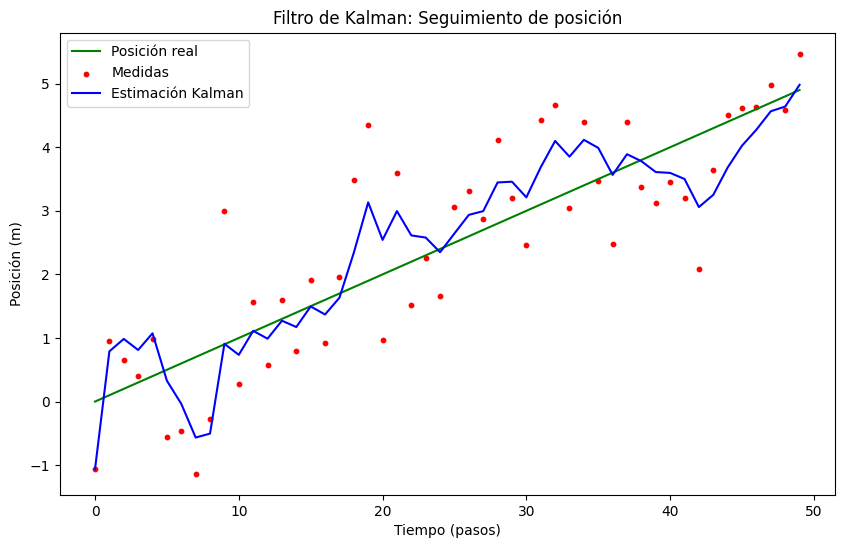

In [3]:
import matplotlib.pyplot as plt

# Simulamos datos reales y medidas ruidosas
true_positions = []
measurements = []
estimated_positions = []

for t in range(50):
    # Estado real (desconocido en la práctica)
    true_pos = t*dt * 1.0  # velocidad constante de 1 m/s
    
    # Medida ruidosa
    measurement = true_pos + np.random.normal(0, np.sqrt(R[0,0]))
    
    # Aplicamos el filtro de Kalman
    x, P = kalman_filter(x, P, measurement)
    
    # Guardamos resultados
    true_positions.append(true_pos)
    measurements.append(measurement)
    estimated_positions.append(x[0,0])

# Visualización
plt.figure(figsize=(10,6))
plt.plot(true_positions, label='Posición real', color='green')
plt.scatter(range(50), measurements, label='Medidas', color='red', s=10)
plt.plot(estimated_positions, label='Estimación Kalman', color='blue')
plt.legend()
plt.title('Filtro de Kalman: Seguimiento de posición')
plt.xlabel('Tiempo (pasos)')
plt.ylabel('Posición (m)')
plt.show()

## Explicación Detallada del Proceso

### 1. Predicción

**Ecuación de predicción del estado:**
```
xₖ⁻ = F xₖ₋₁
```
- `xₖ⁻`: Estado predicho
- `F`: Matriz de transición
- `xₖ₋₁`: Estado anterior

**Ecuación de predicción de covarianza:**
```
Pₖ⁻ = F Pₖ₋₁ Fᵀ + Q
```
- `Pₖ⁻`: Covarianza predicha
- `Q`: Covarianza del ruido del proceso

### 2. Actualización

**Residual (innovación):**
```
y = z - H xₖ⁻
```
- `z`: Medida actual
- `H`: Matriz de observación

**Covarianza del residual:**
```
S = H Pₖ⁻ Hᵀ + R
```
- `R`: Covarianza del ruido de observación

**Ganancia de Kalman:**
```
K = Pₖ⁻ Hᵀ S⁻¹
```
- `K`: Cuánto peso dar a la medida vs. la predicción

**Actualización del estado:**
```
xₖ = xₖ⁻ + K y
```

**Actualización de la covarianza:**
```
Pₖ = (I - K H) Pₖ⁻
```

## Interpretación de la Ganancia de Kalman

La ganancia de Kalman (`K`) es el "peso" que damos a la nueva medida:
- Si `R` es pequeño (medidas precisas), `K` es grande → damos más peso a la medida
- Si `P` es pequeño (modelo preciso), `K` es pequeño → damos más peso al modelo

## Extensiones del Filtro de Kalman

1. **Filtro de Kalman Extendido (EKF)**: Para sistemas no lineales, usando linealización.
2. **Filtro de Kalman Unscented (UKF)**: Mejor para sistemas fuertemente no lineales.
3. **Filtro de Kalman Ensemble (EnKF)**: Usado en sistemas de gran dimensión (como meteorología).

## Consejos para Implementación

1. **Inicialización**: Es crucial elegir buenos valores iniciales para `x` y `P`.
2. **Sintonización**: Ajustar `Q` y `R` es clave para el buen funcionamiento.
3. **Estabilidad**: Verificar que `P` permanece definida positiva.
4. **Validación**: Siempre probar con datos simulados donde conozcas la verdad.

## Ejercicio Propuesto

Implementa un filtro de Kalman para estimar la posición y velocidad de un objeto que acelera:
- Estado: posición, velocidad, aceleración
- Modelo: xₖ = xₖ₋₁ + vₖ₋₁Δt + ½aₖ₋₁Δt²
- Observación: solo posición

Compara los resultados con y sin aceleración en el modelo.


### Ejemplo de filtro Kalman con coche en movimiento

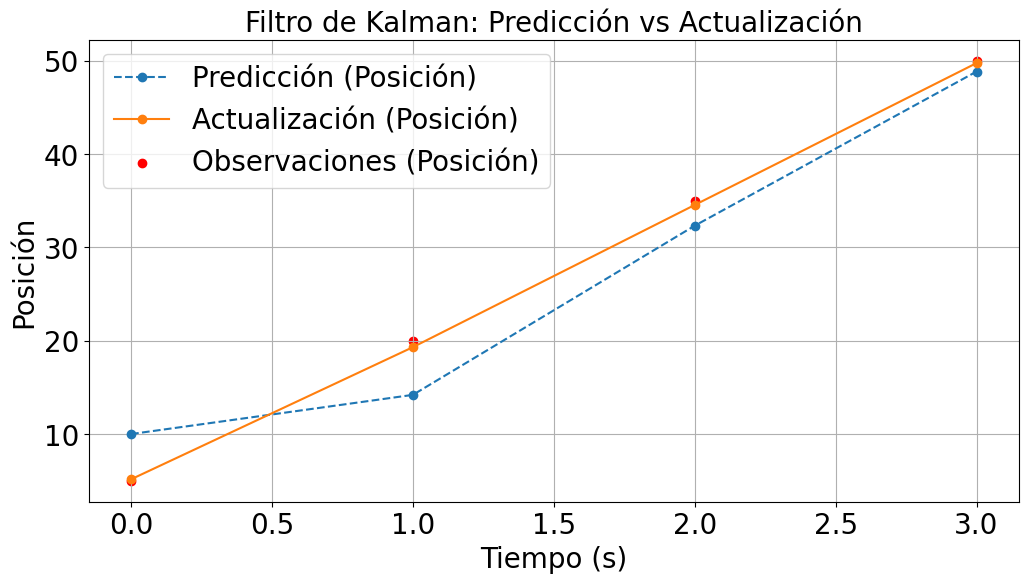

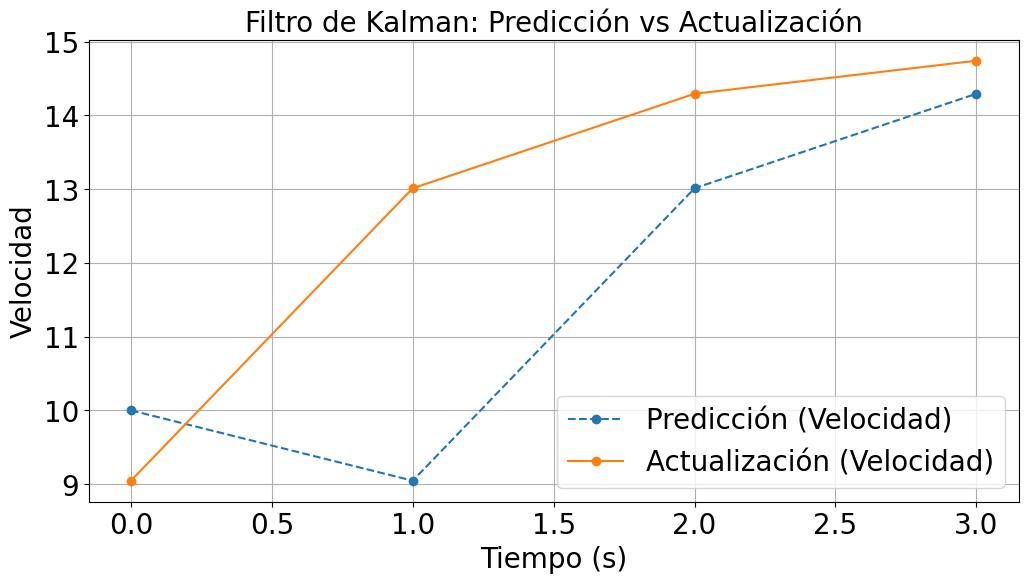

Diferencias entre predicción y actualización:
Tiempo 1:
   Predicción: Posición=10.00, Velocidad=10.00
   Actualización: Posición=5.15, Velocidad=9.05
   Innovación: -5.00

Tiempo 2:
   Predicción: Posición=14.20, Velocidad=9.05
   Actualización: Posición=19.31, Velocidad=13.01
   Innovación: 5.80

Tiempo 3:
   Predicción: Posición=32.32, Velocidad=13.01
   Actualización: Posición=34.54, Velocidad=14.29
   Innovación: 2.68

Tiempo 4:
   Predicción: Posición=48.84, Velocidad=14.29
   Actualización: Posición=49.75, Velocidad=14.74
   Innovación: 1.16



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Inicialización de parámetros
dt = 1  # Intervalo de tiempo (1 segundo)
F = np.array([[1, dt], [0, 1]])  # Matriz de transición del sistema
H = np.array([[1, 0]])  # Operador de observación (solo posición)
Q = np.array([[2, 0], [0, 2]])  # Covarianza del modelo
R = np.array([[4]])  # Covarianza del ruido de observaciones

# Estado inicial (posición y velocidad)
x = np.array([[0], [10]])  # Posición inicial desconocida, velocidad inicial estimada
P = np.array([[100, 0], [0, 25]])  # Covarianza inicial (gran incertidumbre en posición)

# Observaciones (posiciones medidas con ruido)
observations = np.array([5, 20, 35, 50])

# Almacenamiento para graficar resultados
predicted_states = []
updated_states = []
innovations = []

# Filtro de Kalman
for y in observations:
    # Predicción
    x_pred = F @ x
    P_pred = F @ P @ F.T + Q
    
    # Innovación (diferencia entre observación y predicción)
    y_pred = H @ x_pred
    innovation = y - y_pred
    
    # Ganancia de Kalman
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    
    # Actualización
    x_update = x_pred + K @ innovation
    P_update = (np.eye(2) - K @ H) @ P_pred
    
    # Almacenar resultados para análisis
    predicted_states.append(x_pred.flatten())
    updated_states.append(x_update.flatten())
    innovations.append(innovation.flatten())
    
    # Preparar para la siguiente iteración
    x = x_update
    P = P_update

# Convertir resultados a arrays para graficar
predicted_states = np.array(predicted_states)
updated_states = np.array(updated_states)
innovations = np.array(innovations)

# Graficar resultados
time_steps = np.arange(len(observations))

# Cambiar fuentes globalmente (opcional)
plt.rcParams.update({
    'font.size': 20,            # tamaño base
    'axes.titlesize': 20,       # título de la figura
    'axes.labelsize': 20,       # etiquetas de ejes
    'xtick.labelsize': 20,      # ticks del eje x
    'ytick.labelsize': 20,      # ticks del eje y
    'legend.fontsize': 20,      # leyenda
    'figure.titlesize': 20      # título general de figura
})


plt.figure(figsize=(12, 6))
plt.plot(time_steps, predicted_states[:, 0], label="Predicción (Posición)", linestyle="--", marker="o")
plt.plot(time_steps, updated_states[:, 0], label="Actualización (Posición)", linestyle="-", marker="o")
plt.scatter(time_steps, observations, color="red", label="Observaciones (Posición)")
plt.legend()
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición")
plt.title("Filtro de Kalman: Predicción vs Actualización")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time_steps, predicted_states[:, 1], label="Predicción (Velocidad)", linestyle="--", marker="o")
plt.plot(time_steps, updated_states[:, 1], label="Actualización (Velocidad)", linestyle="-", marker="o")
plt.legend()
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad")
plt.title("Filtro de Kalman: Predicción vs Actualización")
plt.grid(True)
plt.show()

print("Diferencias entre predicción y actualización:")
for t in range(len(observations)):
    print(f"Tiempo {t+1}:")
    print(f"   Predicción: Posición={predicted_states[t,0]:.2f}, Velocidad={predicted_states[t,1]:.2f}")
    print(f"   Actualización: Posición={updated_states[t,0]:.2f}, Velocidad={updated_states[t,1]:.2f}")
    print(f"   Innovación: {innovations[t][0]:.2f}\n")
